In [1]:
# Instalação rápida das dependências
!pip install -q diffusers transformers accelerate protobuf

In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


⚡ Carregando modelo ultra-leve no modo: CUDA...


model_index.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

🎨 Gerando imagem via Latent Diffusion...


  0%|          | 0/20 [00:00<?, ?it/s]

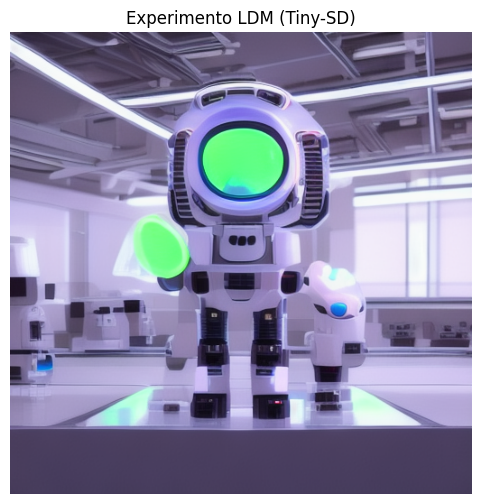

✅ Concluído com sucesso!


In [3]:
# 1. Modelo ultra-leve (~600MB)
model_id = "segmind/tiny-sd"

# Detecta automaticamente GPU ou CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_type = torch.float16 if device == "cuda" else torch.float32

print(f"⚡ Carregando modelo ultra-leve no modo: {device.upper()}...")

# Removido o argumento use_safetensors=True para aceitar os arquivos do repositório
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch_type,
    use_safetensors=False
).to(device)

if device == "cuda":
    pipe.enable_attention_slicing()

# 2. Definição do Prompt
prompt = "A cute glowing robot in a futuristic laboratory, digital art, 8k"

# 3. Execução do Denoising no Espaço Latente (20 passos)
print("🎨 Gerando imagem via Latent Diffusion...")
image = pipe(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=7.0
).images[0]

# 4. Exibição direta no notebook
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Experimento LDM (Tiny-SD)", fontsize=12)
plt.show()

print("✅ Concluído com sucesso!")